# Training Curves Visualization
Comprehensive visualization of all training metrics from the DQN training progress

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the progress CSV
csv_path = '/Users/shashi/Desktop/gatech/soccer-twos-starter/ray_results/DQN_CustomAgent_ObsTransform/DQN_SoccerCustomDQN_5623b_00000_0_2026-04-18_17-34-10/progress.csv'
df = pd.read_csv(csv_path)

print(f"Data shape: {df.shape}")
print(f"\nAvailable columns: {df.columns.tolist()}")

Data shape: (619, 76)

Available columns: ['episode_reward_max', 'episode_reward_min', 'episode_reward_mean', 'episode_len_mean', 'episodes_this_iter', 'num_healthy_workers', 'num_agent_steps_sampled', 'num_agent_steps_trained', 'num_env_steps_sampled', 'num_env_steps_trained', 'num_env_steps_sampled_this_iter', 'num_env_steps_trained_this_iter', 'timesteps_total', 'agent_timesteps_total', 'done', 'episodes_total', 'training_iteration', 'trial_id', 'experiment_id', 'date', 'timestamp', 'time_this_iter_s', 'time_total_s', 'pid', 'hostname', 'node_ip', 'time_since_restore', 'timesteps_since_restore', 'iterations_since_restore', 'warmup_time', 'info/num_env_steps_sampled', 'info/num_env_steps_trained', 'info/num_agent_steps_sampled', 'info/num_agent_steps_trained', 'info/last_target_update_ts', 'sampler_results/episode_reward_max', 'sampler_results/episode_reward_min', 'sampler_results/episode_reward_mean', 'sampler_results/episode_len_mean', 'sampler_results/episodes_this_iter', 'hist_st

## Episode Rewards

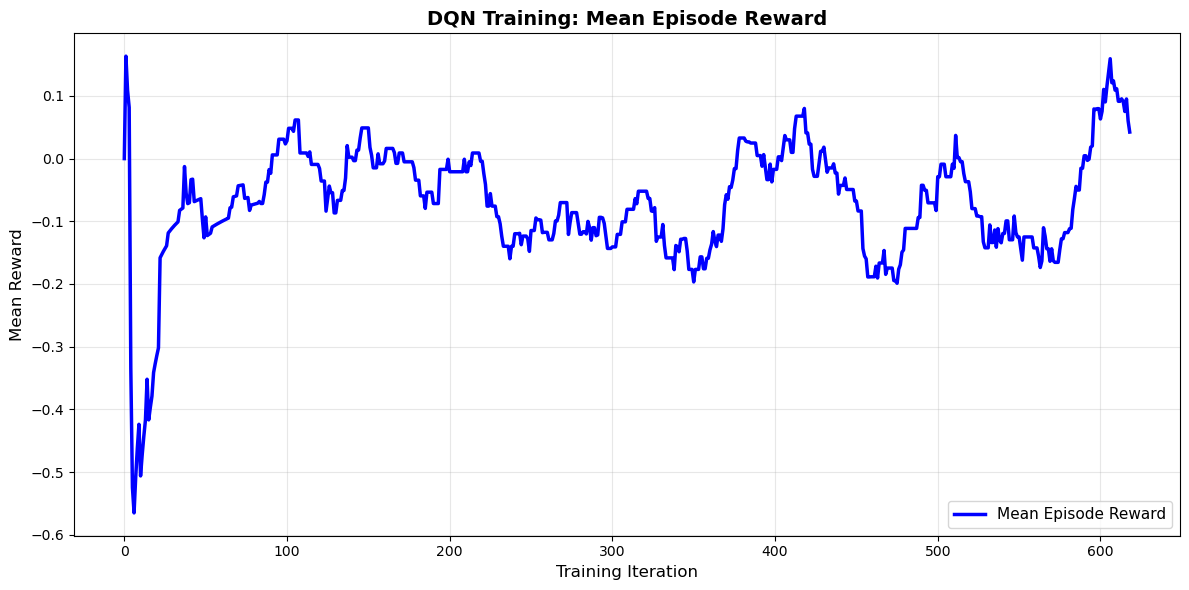

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['episode_reward_mean'], label='Mean Episode Reward', color='blue', linewidth=2.5)
plt.xlabel('Training Iteration', fontsize=12)
plt.ylabel('Mean Reward', fontsize=12)
plt.title('DQN Training: Mean Episode Reward', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure as PNG image
output_path = '/Users/shashi/Desktop/gatech/soccer-twos-starter/mean_reward_curve.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', format='png')
print(f"Figure saved to: {output_path}")

plt.show()

## Episode Length Metrics

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Episode Length Metrics', fontsize=16, fontweight='bold')

# Episode Length Mean
axes[0].plot(df.index, df['episode_len_mean'], label='Mean Length', color='darkblue', linewidth=2)
axes[0].set_xlabel('Training Iteration')
axes[0].set_ylabel('Length (steps)')
axes[0].set_title('Mean Episode Length')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Episodes This Iteration
axes[1].bar(df.index, df['episodes_this_iter'], color='skyblue', alpha=0.7, edgecolor='darkblue')
axes[1].set_xlabel('Training Iteration')
axes[1].set_ylabel('Number of Episodes')
axes[1].set_title('Episodes Completed per Iteration')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## Sampling and Training Steps

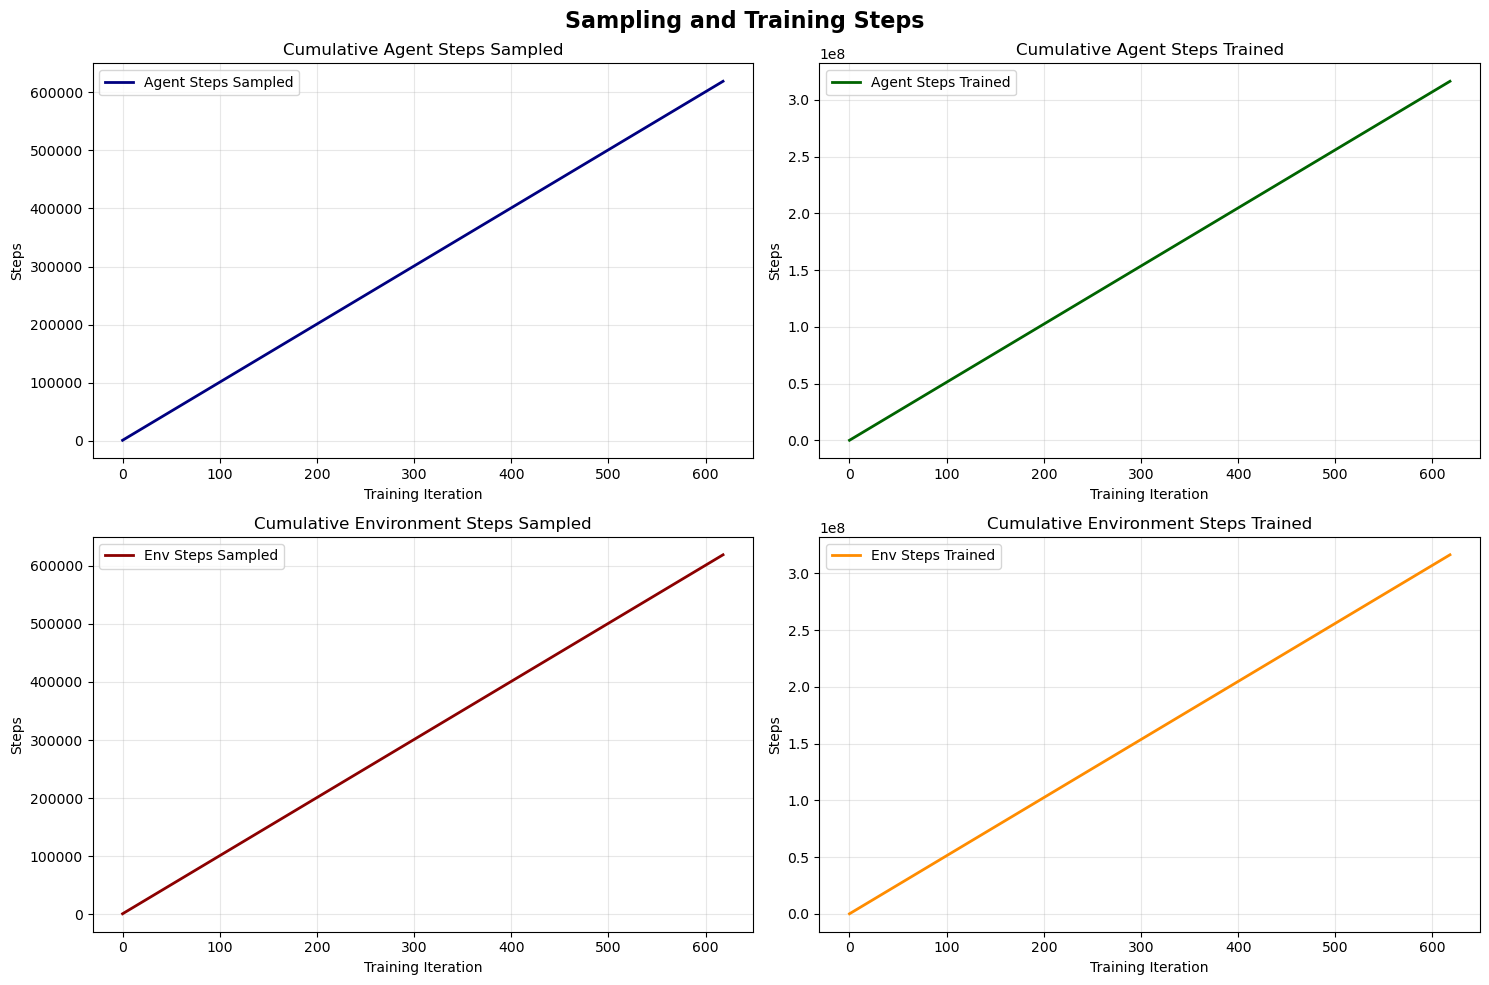

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sampling and Training Steps', fontsize=16, fontweight='bold')

# Agent Steps Sampled
axes[0, 0].plot(df.index, df['num_agent_steps_sampled'], label='Agent Steps Sampled', color='navy', linewidth=2)
axes[0, 0].set_xlabel('Training Iteration')
axes[0, 0].set_ylabel('Steps')
axes[0, 0].set_title('Cumulative Agent Steps Sampled')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Agent Steps Trained
axes[0, 1].plot(df.index, df['num_agent_steps_trained'], label='Agent Steps Trained', color='darkgreen', linewidth=2)
axes[0, 1].set_xlabel('Training Iteration')
axes[0, 1].set_ylabel('Steps')
axes[0, 1].set_title('Cumulative Agent Steps Trained')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Environment Steps Sampled
axes[1, 0].plot(df.index, df['num_env_steps_sampled'], label='Env Steps Sampled', color='darkred', linewidth=2)
axes[1, 0].set_xlabel('Training Iteration')
axes[1, 0].set_ylabel('Steps')
axes[1, 0].set_title('Cumulative Environment Steps Sampled')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Environment Steps Trained
axes[1, 1].plot(df.index, df['num_env_steps_trained'], label='Env Steps Trained', color='darkorange', linewidth=2)
axes[1, 1].set_xlabel('Training Iteration')
axes[1, 1].set_ylabel('Steps')
axes[1, 1].set_title('Cumulative Environment Steps Trained')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## TD Error (Temporal Difference Error)

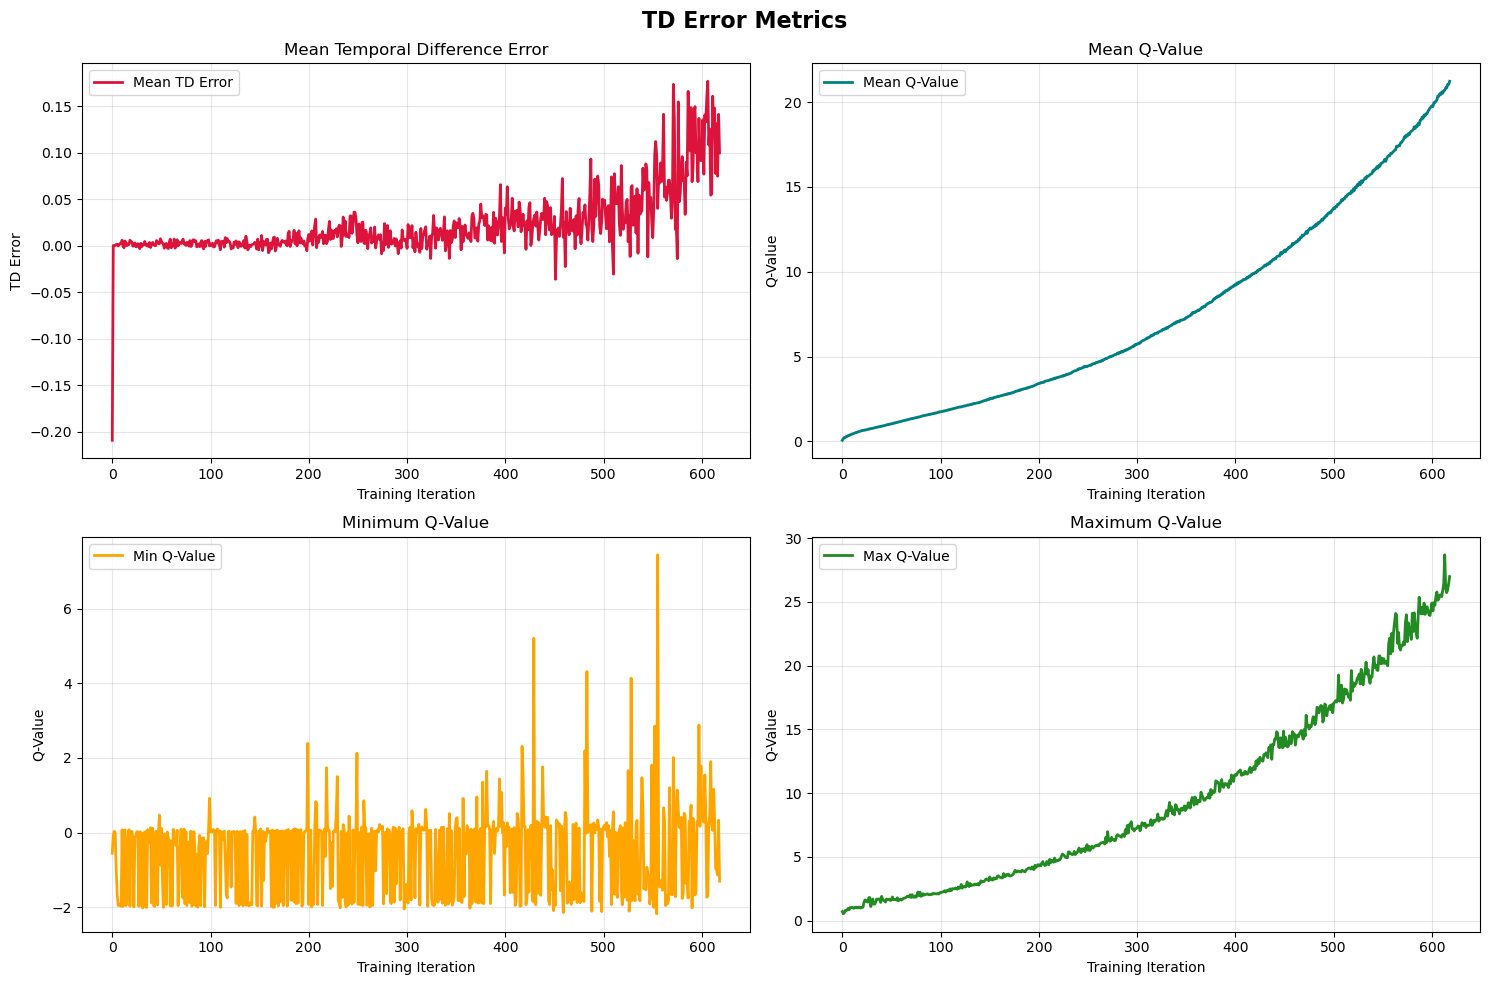

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('TD Error Metrics', fontsize=16, fontweight='bold')

if 'info/learner/default_policy/mean_td_error' in df.columns:
    # Mean TD Error
    axes[0, 0].plot(df.index, df['info/learner/default_policy/mean_td_error'], 
                   label='Mean TD Error', color='crimson', linewidth=2)
    axes[0, 0].set_xlabel('Training Iteration')
    axes[0, 0].set_ylabel('TD Error')
    axes[0, 0].set_title('Mean Temporal Difference Error')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

if 'info/learner/default_policy/learner_stats/mean_q' in df.columns:
    # Mean Q-Value
    axes[0, 1].plot(df.index, df['info/learner/default_policy/learner_stats/mean_q'], 
                   label='Mean Q-Value', color='teal', linewidth=2)
    axes[0, 1].set_xlabel('Training Iteration')
    axes[0, 1].set_ylabel('Q-Value')
    axes[0, 1].set_title('Mean Q-Value')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

if 'info/learner/default_policy/learner_stats/min_q' in df.columns:
    # Min Q-Value
    axes[1, 0].plot(df.index, df['info/learner/default_policy/learner_stats/min_q'], 
                   label='Min Q-Value', color='orange', linewidth=2)
    axes[1, 0].set_xlabel('Training Iteration')
    axes[1, 0].set_ylabel('Q-Value')
    axes[1, 0].set_title('Minimum Q-Value')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

if 'info/learner/default_policy/learner_stats/max_q' in df.columns:
    # Max Q-Value
    axes[1, 1].plot(df.index, df['info/learner/default_policy/learner_stats/max_q'], 
                   label='Max Q-Value', color='forestgreen', linewidth=2)
    axes[1, 1].set_xlabel('Training Iteration')
    axes[1, 1].set_ylabel('Q-Value')
    axes[1, 1].set_title('Maximum Q-Value')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Learning Rate and Gradient Metrics

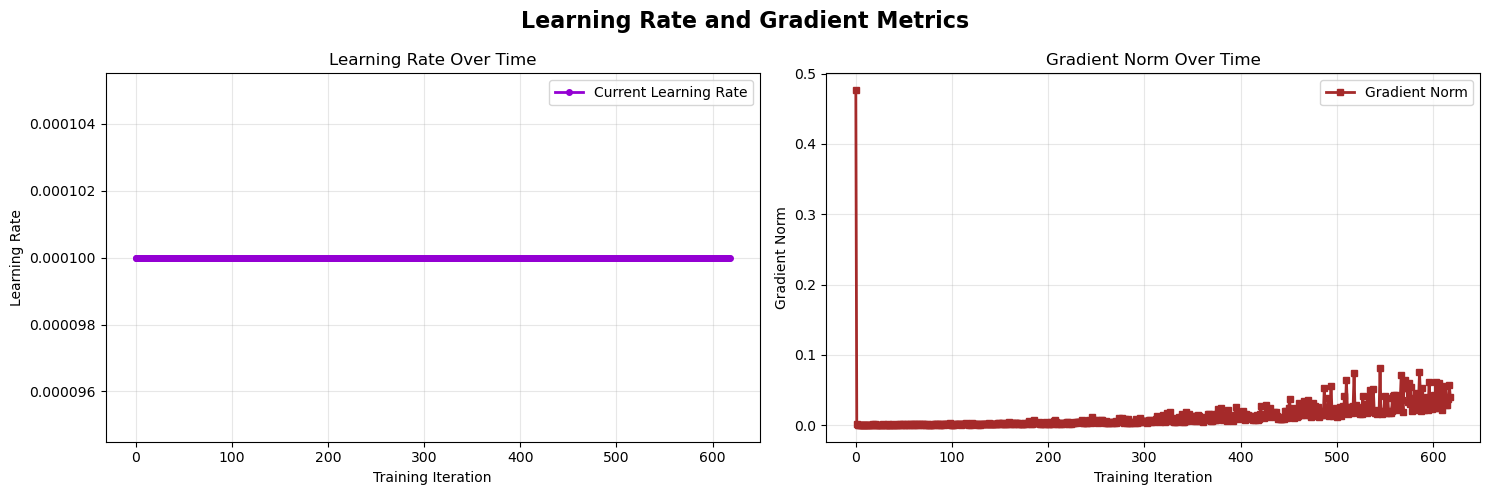

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Learning Rate and Gradient Metrics', fontsize=16, fontweight='bold')

if 'info/learner/default_policy/learner_stats/cur_lr' in df.columns:
    # Current Learning Rate
    axes[0].plot(df.index, df['info/learner/default_policy/learner_stats/cur_lr'], 
                label='Current Learning Rate', color='darkviolet', linewidth=2, marker='o', markersize=4)
    axes[0].set_xlabel('Training Iteration')
    axes[0].set_ylabel('Learning Rate')
    axes[0].set_title('Learning Rate Over Time')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

if 'info/learner/default_policy/learner_stats/grad_gnorm' in df.columns:
    # Gradient Norm
    axes[1].plot(df.index, df['info/learner/default_policy/learner_stats/grad_gnorm'], 
                label='Gradient Norm', color='brown', linewidth=2, marker='s', markersize=4)
    axes[1].set_xlabel('Training Iteration')
    axes[1].set_ylabel('Gradient Norm')
    axes[1].set_title('Gradient Norm Over Time')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

## Training Timing Metrics

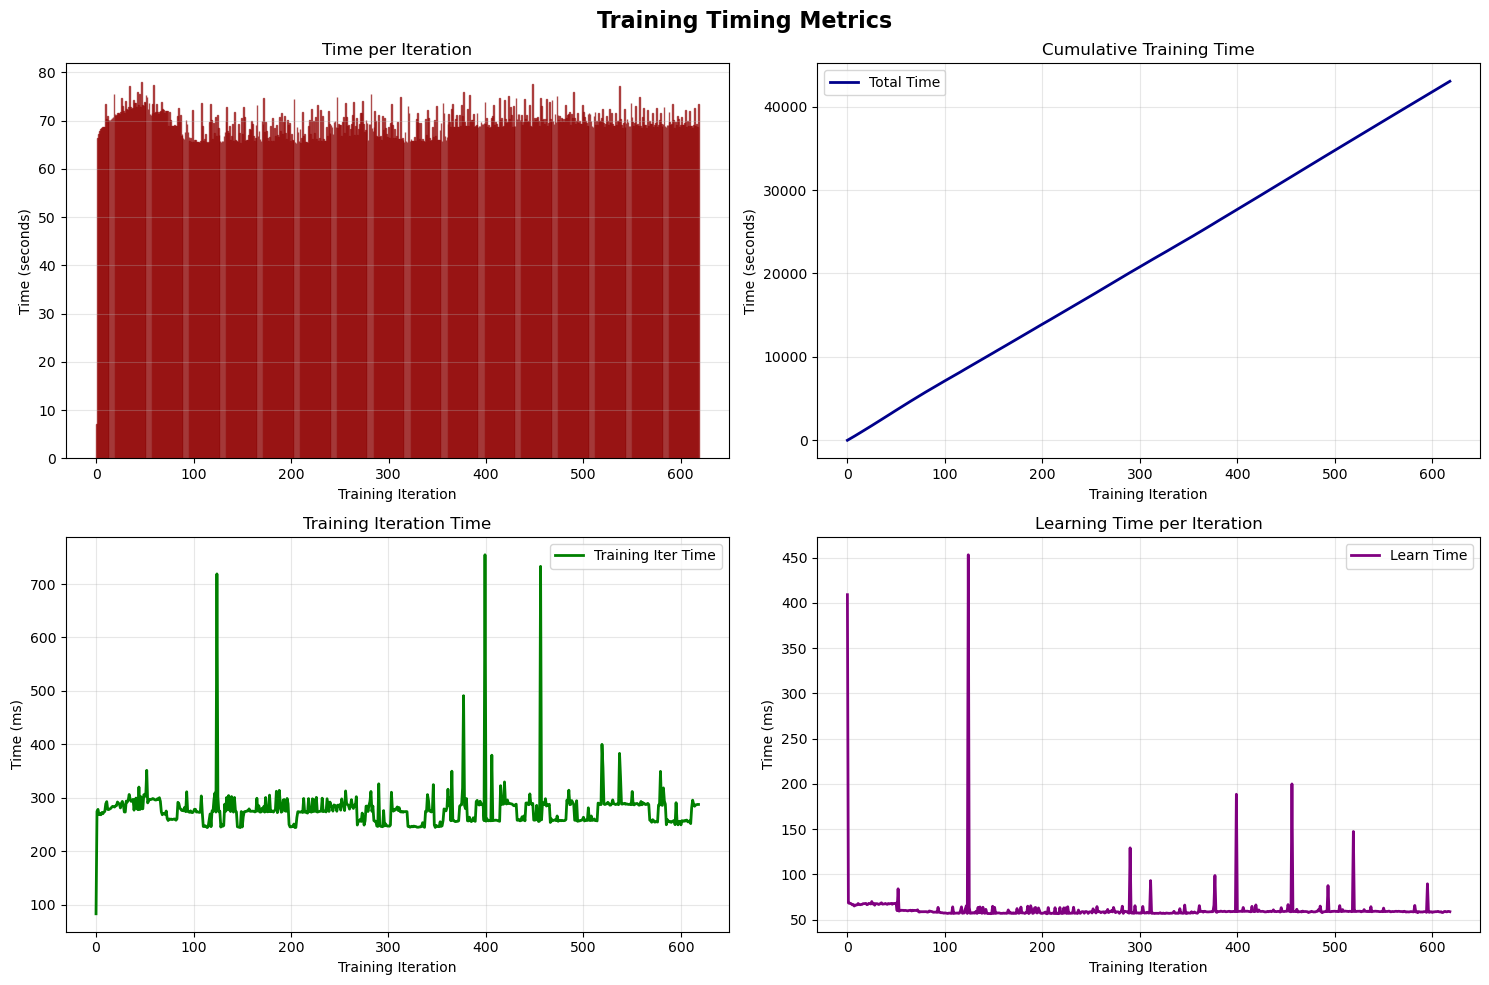

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training Timing Metrics', fontsize=16, fontweight='bold')

# Time per Iteration
axes[0, 0].bar(df.index, df['time_this_iter_s'], color='lightcoral', alpha=0.7, edgecolor='darkred')
axes[0, 0].set_xlabel('Training Iteration')
axes[0, 0].set_ylabel('Time (seconds)')
axes[0, 0].set_title('Time per Iteration')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Total Training Time
axes[0, 1].plot(df.index, df['time_total_s'], label='Total Time', color='darkblue', linewidth=2)
axes[0, 1].set_xlabel('Training Iteration')
axes[0, 1].set_ylabel('Time (seconds)')
axes[0, 1].set_title('Cumulative Training Time')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

if 'timers/training_iteration_time_ms' in df.columns:
    # Training Iteration Time
    axes[1, 0].plot(df.index, df['timers/training_iteration_time_ms'], 
                   label='Training Iter Time', color='green', linewidth=2)
    axes[1, 0].set_xlabel('Training Iteration')
    axes[1, 0].set_ylabel('Time (ms)')
    axes[1, 0].set_title('Training Iteration Time')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

if 'timers/learn_time_ms' in df.columns:
    # Learn Time
    axes[1, 1].plot(df.index, df['timers/learn_time_ms'], 
                   label='Learn Time', color='purple', linewidth=2)
    axes[1, 1].set_xlabel('Training Iteration')
    axes[1, 1].set_ylabel('Time (ms)')
    axes[1, 1].set_title('Learning Time per Iteration')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Sampler Performance Metrics

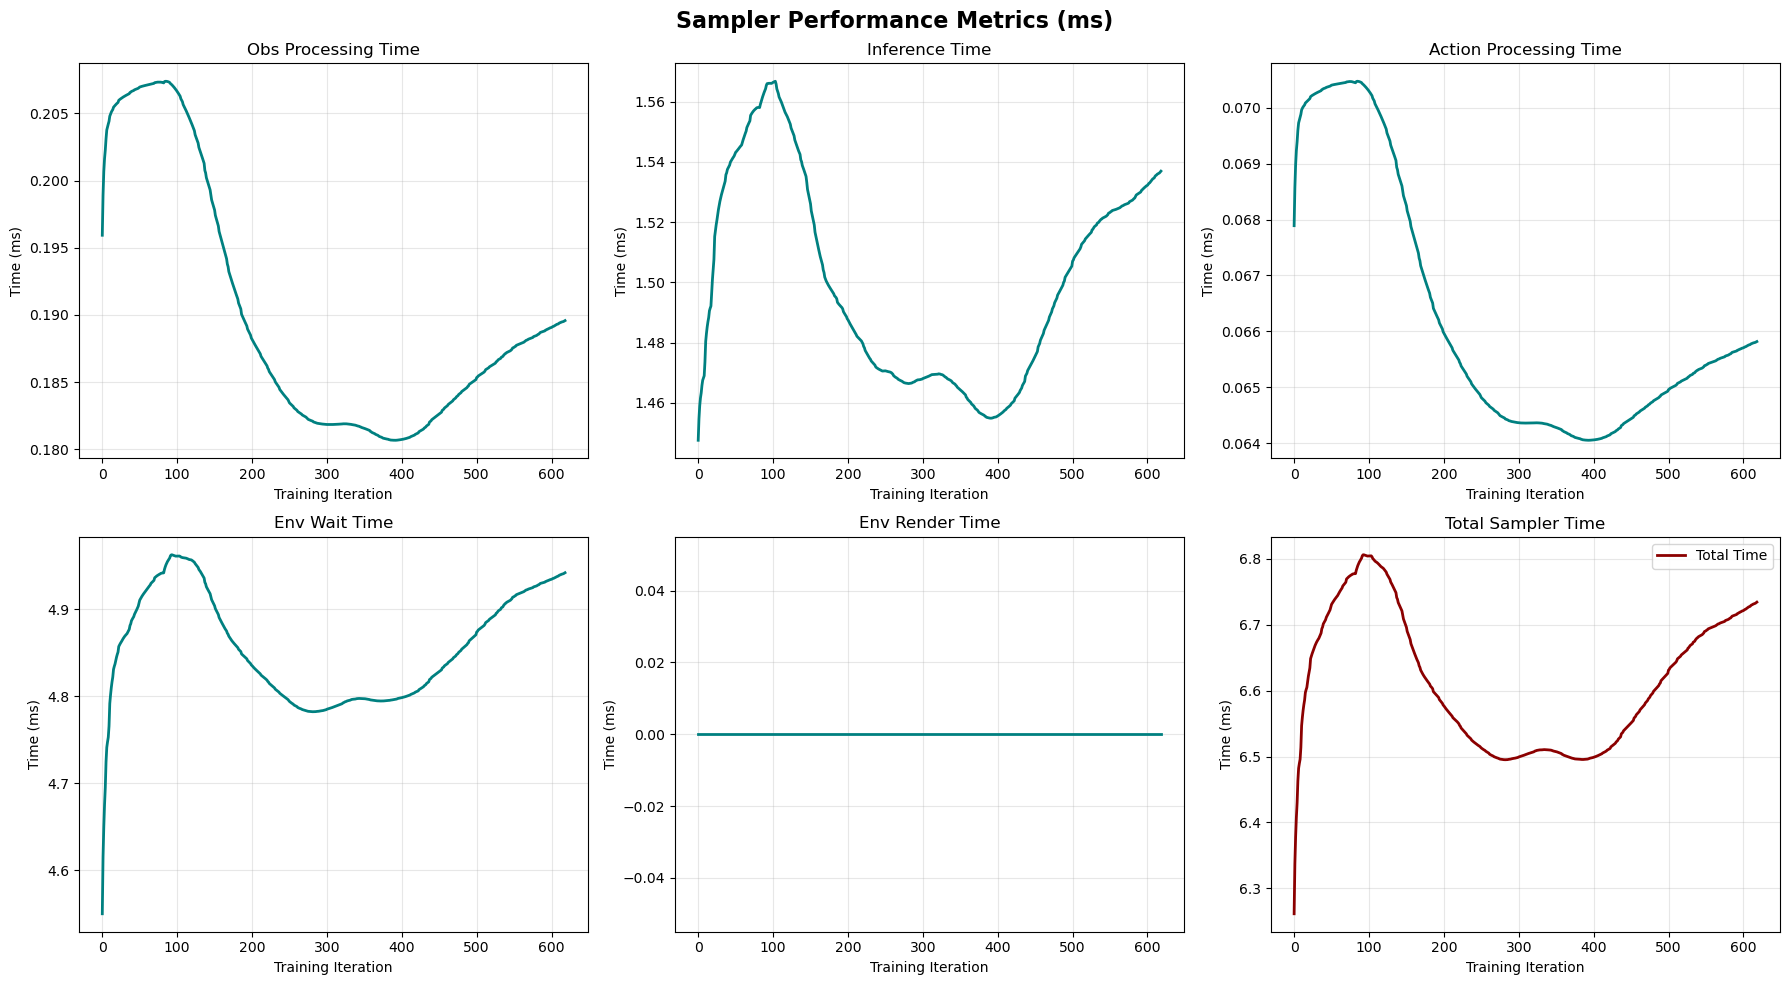

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sampler Performance Metrics (ms)', fontsize=16, fontweight='bold')

metrics = [
    ('sampler_perf/mean_raw_obs_processing_ms', 'Obs Processing Time', axes[0, 0]),
    ('sampler_perf/mean_inference_ms', 'Inference Time', axes[0, 1]),
    ('sampler_perf/mean_action_processing_ms', 'Action Processing Time', axes[0, 2]),
    ('sampler_perf/mean_env_wait_ms', 'Env Wait Time', axes[1, 0]),
    ('sampler_perf/mean_env_render_ms', 'Env Render Time', axes[1, 1]),
]

for col, title, ax in metrics:
    if col in df.columns:
        ax.plot(df.index, df[col], linewidth=2, color='teal')
        ax.set_xlabel('Training Iteration')
        ax.set_ylabel('Time (ms)')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

# Total Time Breakdown
ax = axes[1, 2]
if all(col in df.columns for col in ['sampler_perf/mean_raw_obs_processing_ms', 
                                        'sampler_perf/mean_inference_ms', 
                                        'sampler_perf/mean_action_processing_ms',
                                        'sampler_perf/mean_env_wait_ms']):
    total_time = (df['sampler_perf/mean_raw_obs_processing_ms'] + 
                 df['sampler_perf/mean_inference_ms'] + 
                 df['sampler_perf/mean_action_processing_ms'] + 
                 df['sampler_perf/mean_env_wait_ms'])
    ax.plot(df.index, total_time, label='Total Time', color='darkred', linewidth=2)
    ax.set_xlabel('Training Iteration')
    ax.set_ylabel('Time (ms)')
    ax.set_title('Total Sampler Time')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Resource Utilization

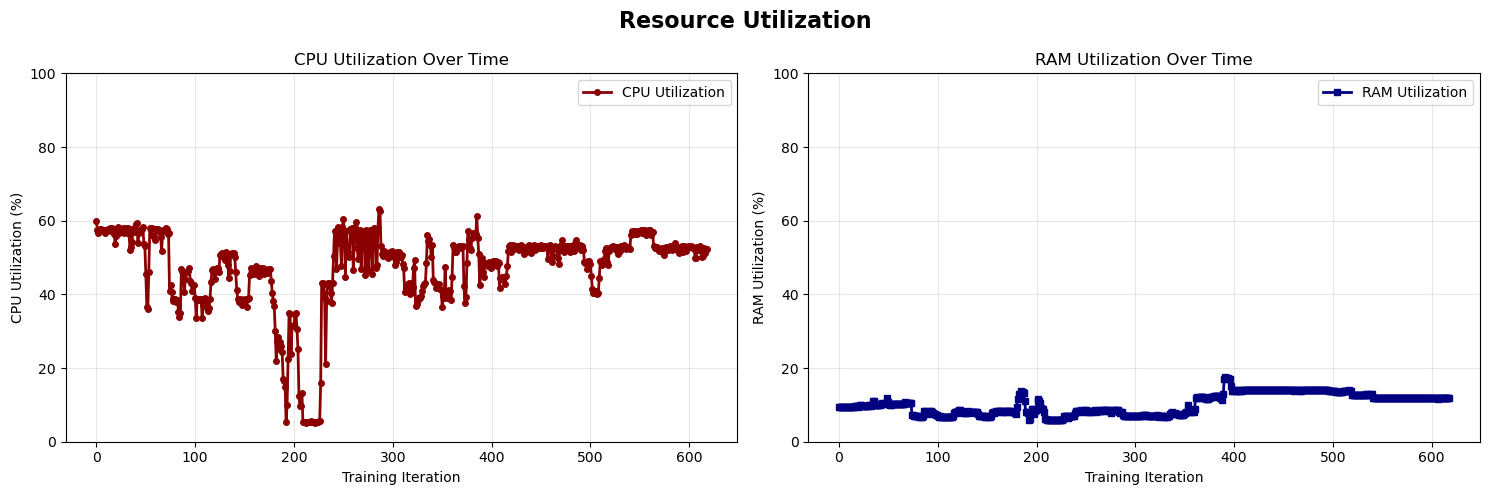

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Resource Utilization', fontsize=16, fontweight='bold')

if 'perf/cpu_util_percent' in df.columns:
    axes[0].plot(df.index, df['perf/cpu_util_percent'], label='CPU Utilization', 
                color='darkred', linewidth=2, marker='o', markersize=4)
    axes[0].set_xlabel('Training Iteration')
    axes[0].set_ylabel('CPU Utilization (%)')
    axes[0].set_title('CPU Utilization Over Time')
    axes[0].set_ylim([0, 100])
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

if 'perf/ram_util_percent' in df.columns:
    axes[1].plot(df.index, df['perf/ram_util_percent'], label='RAM Utilization', 
                color='navy', linewidth=2, marker='s', markersize=4)
    axes[1].set_xlabel('Training Iteration')
    axes[1].set_ylabel('RAM Utilization (%)')
    axes[1].set_title('RAM Utilization Over Time')
    axes[1].set_ylim([0, 100])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

## Summary Statistics

In [10]:
print("="*80)
print("TRAINING SUMMARY STATISTICS")
print("="*80)
print(f"\nTotal Iterations: {len(df)}")
print(f"Total Training Time: {df['time_total_s'].iloc[-1]:.2f} seconds ({df['time_total_s'].iloc[-1]/3600:.2f} hours)")
print(f"\nEpisode Rewards:")
print(f"  Final Mean Reward: {df['episode_reward_mean'].iloc[-1]:.4f}")
print(f"  Max Mean Reward: {df['episode_reward_mean'].max():.4f} (at iteration {df['episode_reward_mean'].idxmax()})")
print(f"  Min Mean Reward: {df['episode_reward_mean'].min():.4f} (at iteration {df['episode_reward_mean'].idxmin()})")
print(f"  Improvement: {df['episode_reward_mean'].iloc[-1] - df['episode_reward_mean'].iloc[0]:.4f}")

print(f"\nEpisode Lengths:")
print(f"  Final Mean Length: {df['episode_len_mean'].iloc[-1]:.1f} steps")
print(f"  Max Mean Length: {df['episode_len_mean'].max():.1f} steps")
print(f"  Min Mean Length: {df['episode_len_mean'].min():.1f} steps")

print(f"\nTotal Cumulative Steps:")
print(f"  Agent Steps Sampled: {df['num_agent_steps_sampled'].iloc[-1]:,.0f}")
print(f"  Agent Steps Trained: {df['num_agent_steps_trained'].iloc[-1]:,.0f}")
print(f"  Env Steps Sampled: {df['num_env_steps_sampled'].iloc[-1]:,.0f}")
print(f"  Env Steps Trained: {df['num_env_steps_trained'].iloc[-1]:,.0f}")

print(f"\nTotal Episodes: {df['episodes_total'].iloc[-1]:,.0f}")
print(f"Total Episodes This Iter: {df['episodes_this_iter'].sum():,.0f}")

if 'perf/cpu_util_percent' in df.columns:
    print(f"\nResource Utilization (Average):")
    print(f"  CPU: {df['perf/cpu_util_percent'].mean():.1f}%")
    print(f"  RAM: {df['perf/ram_util_percent'].mean():.1f}%")

if 'info/learner/default_policy/learner_stats/cur_lr' in df.columns:
    print(f"\nLearning Rate:")
    print(f"  Initial: {df['info/learner/default_policy/learner_stats/cur_lr'].iloc[0]:.6f}")
    print(f"  Final: {df['info/learner/default_policy/learner_stats/cur_lr'].iloc[-1]:.6f}")

print(f"\nTiming (Average per Iteration):")
print(f"  Time per Iteration: {df['time_this_iter_s'].mean():.2f} seconds")
if 'timers/learn_time_ms' in df.columns:
    print(f"  Learn Time: {df['timers/learn_time_ms'].mean():.2f} ms")
if 'timers/training_iteration_time_ms' in df.columns:
    print(f"  Training Iteration Time: {df['timers/training_iteration_time_ms'].mean():.2f} ms")

TRAINING SUMMARY STATISTICS

Total Iterations: 619
Total Training Time: 43033.76 seconds (11.95 hours)

Episode Rewards:
  Final Mean Reward: 0.0423
  Max Mean Reward: 0.1634 (at iteration 1)
  Min Mean Reward: -0.5652 (at iteration 6)
  Improvement: 0.0423

Episode Lengths:
  Final Mean Length: 682.0 steps
  Max Mean Length: 999.0 steps
  Min Mean Length: 662.3 steps

Total Cumulative Steps:
  Agent Steps Sampled: 619,000
  Agent Steps Trained: 316,418,048
  Env Steps Sampled: 619,000
  Env Steps Trained: 316,418,048

Total Episodes: 777
Total Episodes This Iter: 777

Resource Utilization (Average):
  CPU: 47.3%
  RAM: 10.2%

Learning Rate:
  Initial: 0.000100
  Final: 0.000100

Timing (Average per Iteration):
  Time per Iteration: 69.52 seconds
  Learn Time: 61.60 ms
  Training Iteration Time: 277.94 ms


## Available Columns Reference

In [11]:
# Display all available columns grouped by category
print("\nAll Available Columns:")
print("="*80)

categories = {
    'Reward Metrics': [col for col in df.columns if 'reward' in col.lower()],
    'Episode Metrics': [col for col in df.columns if 'episode' in col.lower() or 'length' in col.lower()],
    'Step Counters': [col for col in df.columns if 'step' in col.lower() or 'timestep' in col.lower()],
    'TD Error & Q-Values': [col for col in df.columns if 'td_error' in col.lower() or 'mean_q' in col.lower() or 'min_q' in col.lower() or 'max_q' in col.lower()],
    'Learning Metrics': [col for col in df.columns if 'cur_lr' in col.lower() or 'grad' in col.lower()],
    'Timing': [col for col in df.columns if 'time' in col.lower() or 'timer' in col.lower()],
    'Performance': [col for col in df.columns if 'perf' in col.lower() or 'sampler' in col.lower()],
    'System': [col for col in df.columns if col in ['pid', 'hostname', 'node_ip', 'done', 'training_iteration']],
}

for category, cols in categories.items():
    if cols:
        print(f"\n{category}:")
        for col in sorted(cols):
            print(f"  - {col}")

print(f"\nTotal columns: {len(df.columns)}")


All Available Columns:

Reward Metrics:
  - episode_reward_max
  - episode_reward_mean
  - episode_reward_min
  - hist_stats/episode_reward
  - sampler_results/episode_reward_max
  - sampler_results/episode_reward_mean
  - sampler_results/episode_reward_min
  - sampler_results/hist_stats/episode_reward

Episode Metrics:
  - episode_len_mean
  - episode_reward_max
  - episode_reward_mean
  - episode_reward_min
  - episodes_this_iter
  - episodes_total
  - hist_stats/episode_lengths
  - hist_stats/episode_reward
  - sampler_results/episode_len_mean
  - sampler_results/episode_reward_max
  - sampler_results/episode_reward_mean
  - sampler_results/episode_reward_min
  - sampler_results/episodes_this_iter
  - sampler_results/hist_stats/episode_lengths
  - sampler_results/hist_stats/episode_reward

Step Counters:
  - agent_timesteps_total
  - counters/num_agent_steps_sampled
  - counters/num_agent_steps_trained
  - counters/num_env_steps_sampled
  - counters/num_env_steps_trained
  - info/l